In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,recall_score,precision_score,f1_score
from sklearn.model_selection import GridSearchCV

In [2]:
train = pd.read_csv("/content/UNSW_NB15_training-set.csv")
test = pd.read_csv("/content/UNSW_NB15_testing-set.csv")
feature=pd.read_csv("/content/NUSW-NB15_features.csv",encoding="Latin1")

In [3]:
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

In [4]:
train.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,Normal,0.0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1.0,2.0,0.0,0.0,0.0,1.0,6.0,0.0,Normal,0.0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1.0,3.0,0.0,0.0,0.0,2.0,6.0,0.0,Normal,0.0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1.0,3.0,1.0,1.0,0.0,2.0,1.0,0.0,Normal,0.0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1.0,40.0,0.0,0.0,0.0,2.0,39.0,0.0,Normal,0.0


In [5]:
feature.head(35)

,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


In [6]:
feature.tail(15)

,No.,Name,Type,Description
34,35,ackdat,Float,"TCP connection setup time, the time between th..."
35,36,is_sm_ips_ports,Binary,If source (1) and destination (3)IP addresses ...
36,37,ct_state_ttl,Integer,No. for each state (6) according to specific r...
37,38,ct_flw_http_mthd,Integer,No. of flows that has methods such as Get and ...
38,39,is_ftp_login,Binary,If the ftp session is accessed by user and pas...
39,40,ct_ftp_cmd,integer,No of flows that has a command in ftp session.
40,41,ct_srv_src,integer,No. of connections that contain the same servi...
41,42,ct_srv_dst,integer,No. of connections that contain the same servi...
42,43,ct_dst_ltm,integer,No. of connections of the same destination add...
43,44,ct_src_ ltm,integer,No. of connections of the same source address ...


In [7]:
train.describe(include="O").T

,count,unique,top,freq
proto,124587,133,tcp,71807
service,124587,13,-,84052
state,124587,9,FIN,69721
attack_cat,124586,10,Normal,56000


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124587 entries, 0 to 124586
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 124587 non-null  int64  
 1   dur                124587 non-null  float64
 2   proto              124587 non-null  object 
 3   service            124587 non-null  object 
 4   state              124587 non-null  object 
 5   spkts              124587 non-null  int64  
 6   dpkts              124587 non-null  int64  
 7   sbytes             124587 non-null  int64  
 8   dbytes             124587 non-null  int64  
 9   rate               124587 non-null  float64
 10  sttl               124587 non-null  int64  
 11  dttl               124587 non-null  int64  
 12  sload              124587 non-null  float64
 13  dload              124587 non-null  float64
 14  sloss              124587 non-null  int64  
 15  dloss              124587 non-null  int64  
 16  si

In [9]:
print("Train missing values:", train.isna().sum().sum())
print("Test missing values:", test.isna().sum().sum())

Train missing values: 25
Test missing values: 0


In [10]:
train.dropna(inplace=True)

In [11]:
test.dropna(inplace=True)

In [12]:
print("Train duplicate rows:", train.duplicated().sum())
print("Test duplicate rows:", test.duplicated().sum())

Train duplicate rows: 0
Test duplicate rows: 0


In [13]:
train.columns

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')

In [14]:


train=train.drop("id",axis=1)

In [15]:
test = test.drop("id", axis=1)

In [16]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
dur,124586.0,1.536800e+00,6.685569e+00,0.0,0.000009,4.797600e-02,8.341945e-01,5.999999e+01
spkts,124586.0,2.509487e+01,1.468772e+02,1.0,2.000000,1.000000e+01,1.800000e+01,9.616000e+03
dpkts,124586.0,2.467774e+01,1.209486e+02,0.0,0.000000,6.000000e+00,1.800000e+01,1.097400e+04
sbytes,124586.0,1.031738e+04,1.867713e+05,28.0,200.000000,7.560000e+02,2.036000e+03,1.296523e+07
dbytes,124586.0,1.946136e+04,1.580637e+05,0.0,0.000000,3.040000e+02,1.910000e+03,1.465555e+07
rate,124586.0,6.121632e+04,1.401399e+05,0.0,27.356544,7.234105e+02,1.111111e+05,1.000000e+06
sttl,124586.0,1.542624e+02,1.085909e+02,0.0,31.000000,2.540000e+02,2.540000e+02,2.550000e+02
dttl,124586.0,9.545426e+01,1.132754e+02,0.0,0.000000,2.900000e+01,2.520000e+02,2.540000e+02
sload,124586.0,6.352979e+07,2.010671e+08,0.0,10178.666995,3.984096e+05,6.720000e+07,5.988000e+09
dload,124586.0,9.408987e+05,2.827976e+06,0.0,0.000000,4.297805e+03,2.197445e+05,2.242273e+07


In [17]:
numeric_cols = train.select_dtypes(include="number").columns.drop(
    "label",
    errors="ignore"
)

skewness = train[numeric_cols].skew().abs()

skewed_cols = skewness[skewness > 1].index

print("Number of skewed features:", len(skewed_cols))
print(skewed_cols.tolist())

Number of skewed features: 33
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


In [18]:
train_log = train.copy()

train_log[skewed_cols] = np.log1p(
    train_log[skewed_cols]
)

In [19]:
test_log = test.copy()
test_log[skewed_cols] = np.log1p(test_log[skewed_cols])

In [20]:
train_log["label"].value_counts()

,count
label,
1.0,68586
0.0,56000


In [21]:
train_log = train_log.drop_duplicates()
test_log = test_log.drop_duplicates()

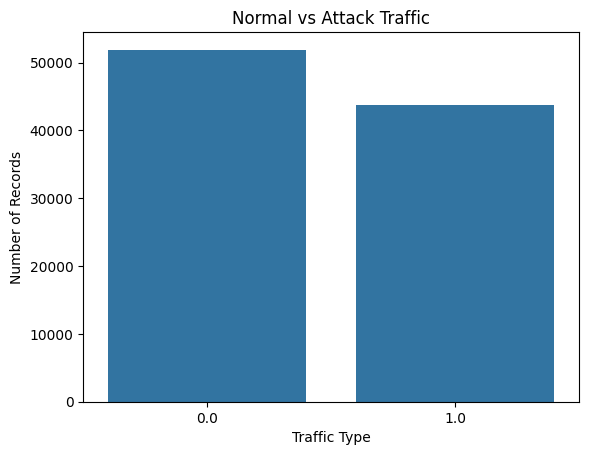

In [22]:
sns.countplot(data=train_log,x='label')
plt.title("Normal vs Attack Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Records")

plt.show()

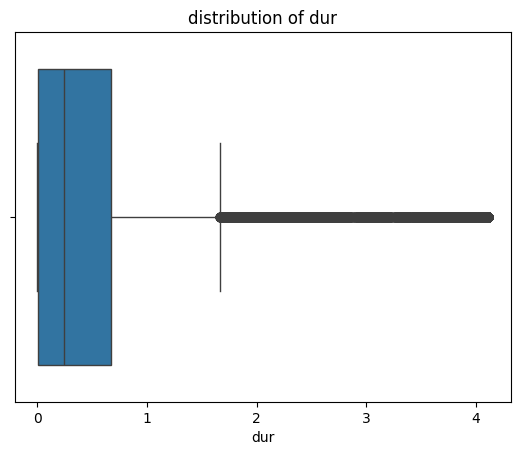

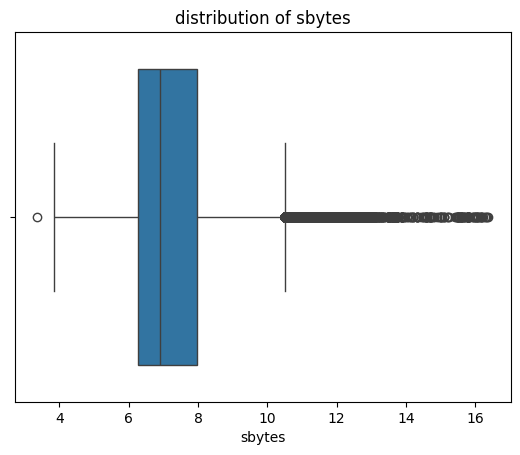

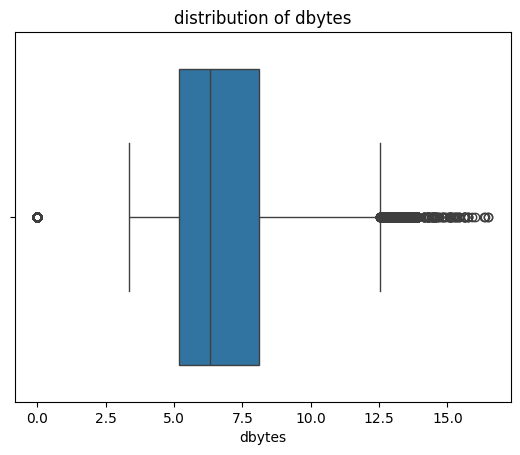

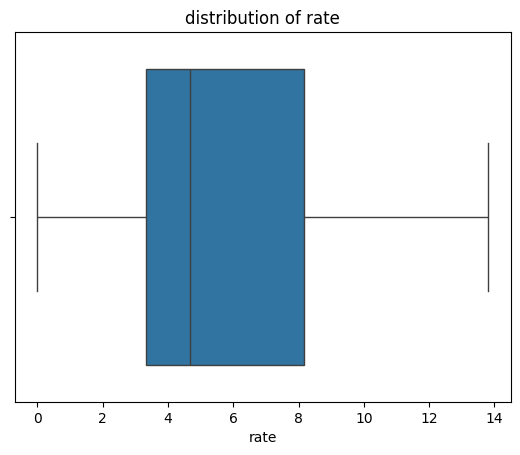

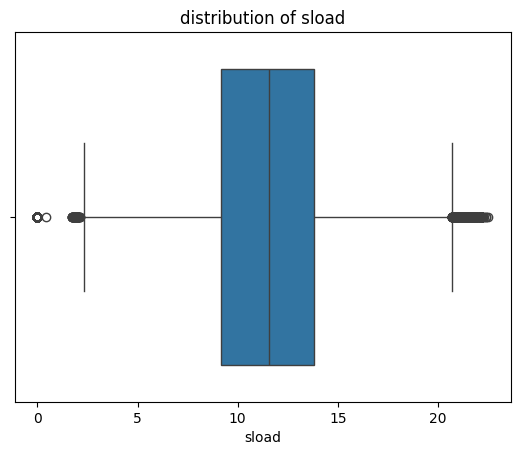

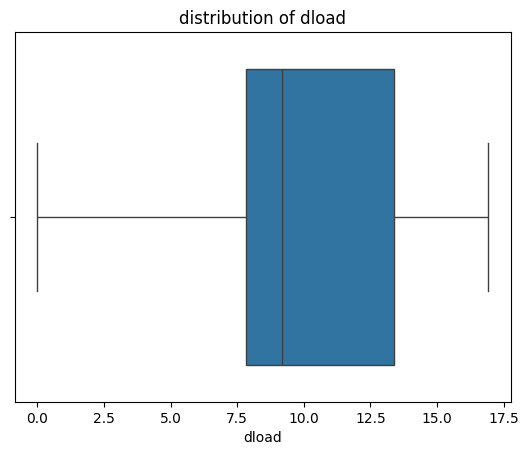

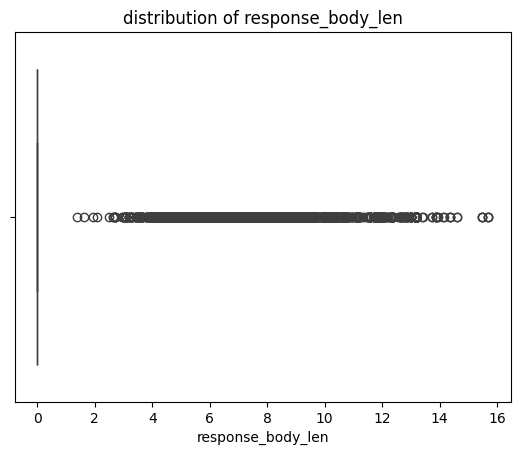

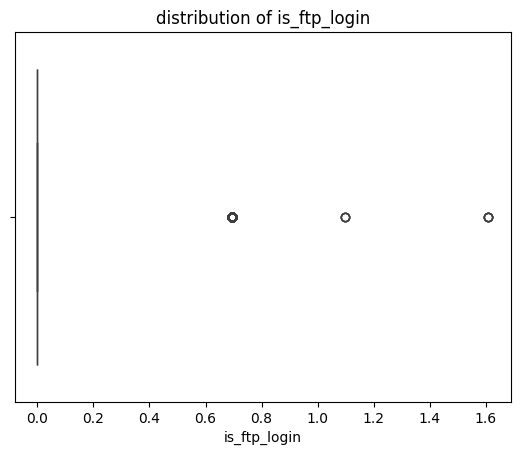

In [51]:

box=["dur","sbytes","dbytes","rate","sload","dload","response_body_len","is_ftp_login"]
for col in box:
  sns.boxplot(data=train_log,x=col)
  plt.title(f"distribution of {col}")
  plt.show()


In [24]:
train_log["is_ftp_login"].value_counts()

,count
is_ftp_login,
0.000000,93938
0.693147,1681
1.609438,5
1.098612,4


In [25]:
train_log.describe(include="O")

,proto,service,state,attack_cat
count,95628,95628,95628,95628
unique,133,13,9,10
top,tcp,-,FIN,Normal
freq,68753,59236,66971,51890


Text(0, 0.5, 'Attack Category')

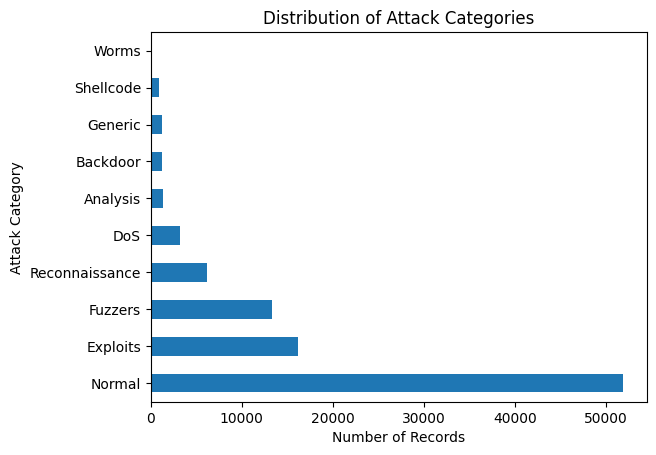

In [26]:
train_log["attack_cat"].value_counts().plot(kind="barh")

plt.title("Distribution of Attack Categories")
plt.xlabel("Number of Records")
plt.ylabel("Attack Category")

<Axes: xlabel='sbytes', ylabel='dbytes'>

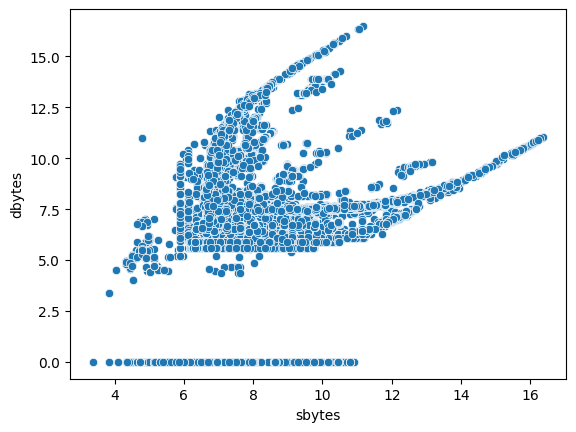

In [27]:
sns.scatterplot(data=train_log,x="sbytes",y="dbytes")

<Axes: xlabel='rate', ylabel='Proportion'>

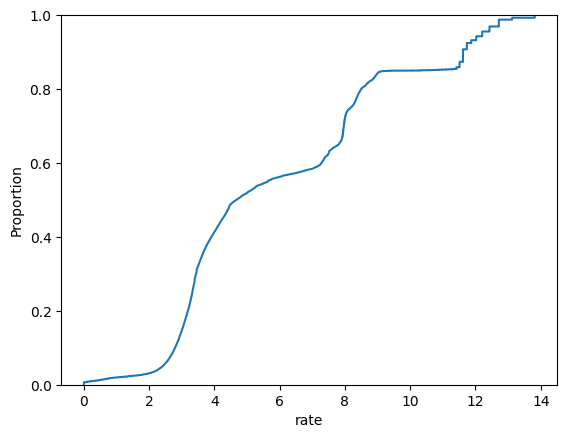

In [28]:
sns.ecdfplot(data=train_log,x="rate")

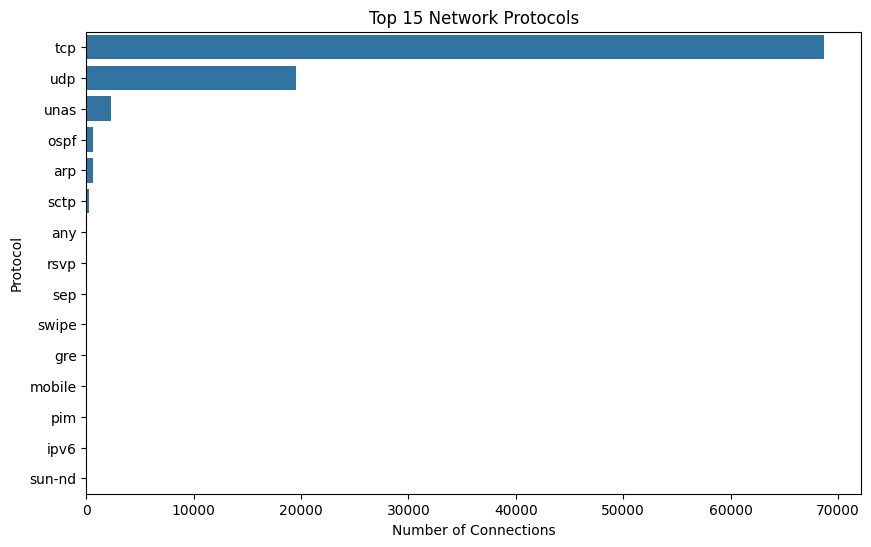

In [29]:

proto_counts = train_log["proto"].value_counts().head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=proto_counts.values,
    y=proto_counts.index
)

plt.title("Top 15 Network Protocols")
plt.xlabel("Number of Connections")
plt.ylabel("Protocol")

plt.show()

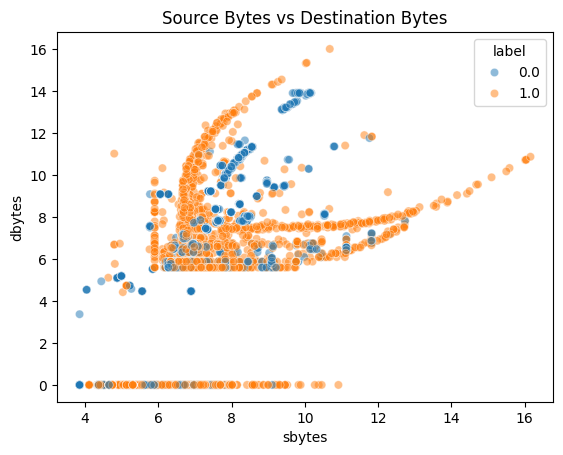

In [30]:
sns.scatterplot(
    data=train_log.sample(
        min(10000, len(train)),
        random_state=42
    ),
    x="sbytes",
    y="dbytes",
    hue="label",
    alpha=0.5
)

plt.title("Source Bytes vs Destination Bytes")
plt.show()

In [33]:
X_train = train_log.drop(["label", "attack_cat"], axis=1)
y_train = train_log["label"]

X_test = test_log.drop(["label", "attack_cat"], axis=1)
y_test = test_log["label"]

In [34]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [35]:
cat = ["proto", "service", "state"]
num = X_tr.columns.drop(cat)


In [36]:

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ("num", StandardScaler(), num)
])

In [38]:
X_tr_processed = pre.fit_transform(X_tr)
X_val_processed = pre.transform(X_val)
X_test_processed= pre.transform(X_test)

In [40]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr_processed, y_tr)
rf_pred = rf.predict(X_val_processed)
print("RF")
print(classification_report(y_val, rf_pred))
print(confusion_matrix(y_val, rf_pred))

RF
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93     10378
         1.0       0.91      0.93      0.92      8748

    accuracy                           0.93     19126
   macro avg       0.93      0.93      0.93     19126
weighted avg       0.93      0.93      0.93     19126



In [43]:
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_tr_processed, y_tr)
xgb_pred = xgb.predict(X_val_processed)
print("XGB")
print(classification_report(y_val, xgb_pred))
print(confusion_matrix(y_val, xgb_pred))

XGB
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94     10378
         1.0       0.92      0.93      0.93      8748

    accuracy                           0.93     19126
   macro avg       0.93      0.93      0.93     19126
weighted avg       0.93      0.93      0.93     19126

[[9654  724]
 [ 577 8171]]


In [42]:
test_pred = xgb.predict(X_test_processed)
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.97      0.78      0.87     34206
           1       0.74      0.96      0.84     21739

    accuracy                           0.85     55945
   macro avg       0.86      0.87      0.85     55945
weighted avg       0.88      0.85      0.86     55945



In [44]:
print(confusion_matrix(y_test, test_pred))

[[26812  7394]
 [  779 20960]]


In [45]:
rf_test = rf.predict(X_test_processed)
print(classification_report(y_test, rf_test))
print(confusion_matrix(y_test, rf_test))

              precision    recall  f1-score   support

           0       0.97      0.78      0.86     34206
           1       0.73      0.97      0.83     21739

    accuracy                           0.85     55945
   macro avg       0.85      0.87      0.85     55945
weighted avg       0.88      0.85      0.85     55945

[[26562  7644]
 [  735 21004]]


In [46]:
probs = xgb.predict_proba(X_val_processed)[:, 1]
for t in [0.4, 0.5, 0.6, 0.7, 0.8]:
    pred = (probs > t).astype(int)
    print(t)
    print(classification_report(y_val, pred))

0.4
              precision    recall  f1-score   support

         0.0       0.96      0.91      0.93     10378
         1.0       0.89      0.96      0.93      8748

    accuracy                           0.93     19126
   macro avg       0.93      0.93      0.93     19126
weighted avg       0.93      0.93      0.93     19126

0.5
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94     10378
         1.0       0.92      0.93      0.93      8748

    accuracy                           0.93     19126
   macro avg       0.93      0.93      0.93     19126
weighted avg       0.93      0.93      0.93     19126

0.6
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.94     10378
         1.0       0.94      0.90      0.92      8748

    accuracy                           0.93     19126
   macro avg       0.93      0.93      0.93     19126
weighted avg       0.93      0.93      0.93     19126

0.7
   

In [49]:
probs_test = xgb.predict_proba(X_test_processed)[:, 1]
for t in [0.5, 0.6, 0.7, 0.8]:
    print(t)
    print(classification_report(y_test, (probs_test > t).astype(int)))

0.5
              precision    recall  f1-score   support

           0       0.97      0.78      0.87     34206
           1       0.74      0.96      0.84     21739

    accuracy                           0.85     55945
   macro avg       0.86      0.87      0.85     55945
weighted avg       0.88      0.85      0.86     55945

0.6
              precision    recall  f1-score   support

           0       0.96      0.84      0.89     34206
           1       0.78      0.94      0.86     21739

    accuracy                           0.88     55945
   macro avg       0.87      0.89      0.87     55945
weighted avg       0.89      0.88      0.88     55945

0.7
              precision    recall  f1-score   support

           0       0.94      0.89      0.91     34206
           1       0.84      0.91      0.87     21739

    accuracy                           0.90     55945
   macro avg       0.89      0.90      0.89     55945
weighted avg       0.90      0.90      0.90     55945

0.8
   

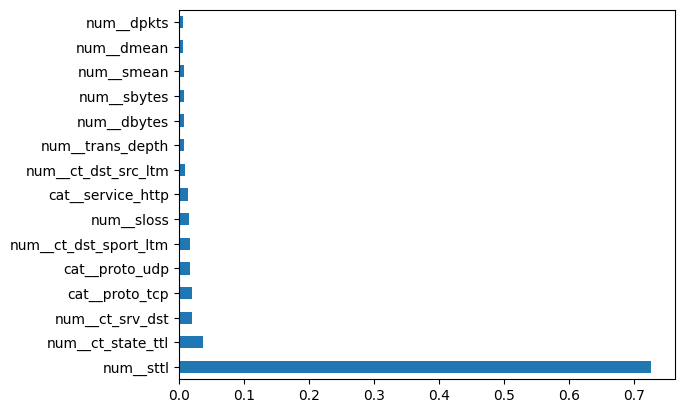

In [48]:
names = pre.get_feature_names_out()
imp = pd.Series(xgb.feature_importances_, index=names)
imp.sort_values(ascending=False).head(15).plot(kind="barh")
plt.show()

In [50]:
params = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 400]
}
gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    params, scoring="f1", cv=3, n_jobs=-1
)
gs.fit(X_tr_processed, y_tr)
print(gs.best_params_)

{'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400}


In [52]:
best = gs.best_estimator_
print(classification_report(y_val, best.predict(X_val_processed)))
print(classification_report(y_test, best.predict(X_test_processed)))
print(confusion_matrix(y_test, best.predict(X_test_processed)))

              precision    recall  f1-score   support

         0.0       0.95      0.93      0.94     10378
         1.0       0.92      0.94      0.93      8748

    accuracy                           0.94     19126
   macro avg       0.94      0.94      0.94     19126
weighted avg       0.94      0.94      0.94     19126

              precision    recall  f1-score   support

           0       0.97      0.78      0.86     34206
           1       0.74      0.96      0.83     21739

    accuracy                           0.85     55945
   macro avg       0.85      0.87      0.85     55945
weighted avg       0.88      0.85      0.85     55945

[[26707  7499]
 [  933 20806]]


In [53]:
results = pd.DataFrame({
    "model": ["RF", "XGB", "XGB tuned"],
    "test_f1": [
        f1_score(y_test, rf.predict(X_test_processed)),
        f1_score(y_test, xgb.predict(X_test_processed)),
        f1_score(y_test, best.predict(X_test_processed))
    ]
})
print(results)

       model   test_f1
0         RF  0.833707
1        XGB  0.836843
2  XGB tuned  0.831508


In [56]:
import joblib
joblib.dump(xgb, "model.pkl")
joblib.dump(skewed_cols.tolist(), "skewed_cols.pkl")
test.sample(200, random_state=42).to_csv("sample_flows.csv", index=False)
!pip show scikit-learn xgboost | grep -E "Name|Version"

Name: scikit-learn
Version: 1.6.1
 Name: GCC runtime library
 Version 3.1, 31 March 2009
Name: xgboost
Version: 3.4.1
